# Comparative Machine Learning Models for Flood Susceptibility Mapping Using Remote Sensing

**Algorithm Focus:** Decision Tree Classifier (CART)

### Introduction
Pluvial floods (surface water flooding) occur when extreme rainfall overwhelms the capacity of natural and artificial drainage systems, leading to severe socio-economic damages in urban areas. Predicting these flood-prone areas is critical for early warning systems and urban planning.

**Project Objective:**
The objective of this notebook is to build a highly accurate machine learning model to detect and predict pluvial flood susceptibility using remote sensing and topographical data.

**Methodology:**
Inspired by the research framework proposed by *Oladapo et al. (2020)*, this project utilizes a two-stage pipeline:
1. **Stage 1 (Feature Engineering):** Applying a Fuzzy Logic rule-based approach to categorize key environmental drivers (`Rainfall` and `Drainage`) into discrete levels to generate a logical baseline prediction.
2. **Stage 2 (Predictive Modeling):** Training a **Decision Tree Classifier** on the combination of raw remote sensing topographical variables and our fuzzy-engineered features to accurately map flood susceptibility.

### Data Dictionary: Feature Columns Explained

Our dataset contains 144,401 geographic data points extracted via remote sensing techniques. Below is a breakdown of the variables used to train our model:

**Geographical Identifiers:**
* **`X` & `Y`**: The spatial coordinates (Longitude and Latitude / Easting and Northing) of the specific land parcel.

**Topographical Variables (Remote Sensing):**
* **`Slope`**: The steepness or incline of the terrain. Steeper slopes typically experience faster runoff, while flat areas are highly prone to water pooling and flooding.
* **`Curvature`**: The geometric shape of the terrain surface (concave, convex, or flat). Concave surfaces tend to concentrate water, increasing flood risk.
* **`Aspect`**: The compass direction that the slope faces, which can affect soil moisture and vegetation.
* **`TWI` (Topographic Wetness Index)**: A highly predictive hydrological index that measures the potential for water accumulation at a specific point based on the upstream contributing area and the local slope.
* **`FA` (Flow Accumulation)**: Represents the total amount of water that is likely to flow into a specific cell from all surrounding higher-elevation cells.

**Environmental Variables:**
* **`Drainage`**: Represents the drainage density or proximity to local drainage networks.
* **`Rainfall`**: The recorded precipitation levels for the area.

**Target Variable:**
* **`SUSCEP`**: The categorized flood susceptibility level (e.g., Very High, High, Moderate, Low, No Flood). *Note: For our Stage 1 preprocessing, we will generate a `Fuzzy_Prediction` target using Fuzzy Logic rules.*


### Target column explanation

`SUSCEP` :

## Stage 1: Clean dataset

* Handle missing values
* Handle NaN Values
* Standardise values

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
pip install openpyxl

In [9]:
!git clone -b dev https://github.com/IamMishael06/Flood-Predictive-Model-School-project-yr-3-.git

Cloning into 'Flood-Predictive-Model-School-project-yr-3-'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 34 (delta 9), reused 26 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 11.39 MiB | 36.45 MiB/s, done.
Resolving deltas: 100% (9/9), done.


In [15]:
df = pd.read_excel('Flood-Predictive-Model-School-project-yr-3-/data/Pluvial_Flood_Dataset.xlsx')

In [14]:
!ls Flood-Predictive-Model-School-project-yr-3-/data

DETECTION-AND-PREDICTION-OF-PLUVIAL-FLOOD-USING-MACHINE-LEARNING-TECHNIQUES.pdf
Pluvial_Flood_Dataset.xlsx


In [17]:
# Run some data informationn here. like getting corrs(), unique values, value counts, e.t.c
df = pd.read_excel('Flood-Predictive-Model-School-project-yr-3-/data/Pluvial_Flood_Dataset.xlsx')
df.drop(columns=["SUSCEP"]).corr()
df.columns = df.columns.str.strip()
df

,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP
0,3.909444,7.443056,46.686142,-3.888000e+09,45.000000,-3.250368,147.0,228.8528,101.515616,Very_High
1,3.908611,7.442778,52.151768,1.296000e+09,60.945396,-4.313832,61.0,229.6781,80.409863,Very_High
2,3.908889,7.442778,66.484085,0.000000e+00,67.619865,-8.327622,1.0,230.5920,78.986849,Very_High
3,3.909167,7.442778,58.007183,-2.592000e+09,38.659809,-4.707937,51.0,235.4210,81.953151,Very_High
4,3.909444,7.442778,60.503792,-1.296000e+09,351.869904,-5.985817,15.0,234.4346,85.866027,Very_High
...,...,...,...,...,...,...,...,...,...,...
144396,3.864167,7.311667,70.837776,1.296000e+09,272.489563,-8.552538,1.0,211.7292,63.087945,Low
144397,3.864444,7.311667,72.578880,1.296000e+09,295.559967,-9.347733,0.0,220.4144,60.489041,Moderate
144398,3.864722,7.311667,70.667946,6.480000e+09,322.125031,-9.236161,0.0,216.3101,62.886849,Low
144399,3.859722,7.311389,61.980232,1.296000e+09,183.814072,-8.819514,0.0,214.3301,66.044932,Low


In [18]:
# subprocess 1 code goes here: Handle missing values
print("\n" + "=" * 70)
print("SUBPROCESS 1: HANDLING MISSING VALUES")
print("=" * 70)

print(f"Missing values per column:\n{df.isna().sum()}")
df = df.dropna()
df.isna().sum()
print(f"Missing values per column after dropping rows with missing values:\n{df.isna().sum()}")
print(f"Dataset shape after missing value handling: {df.shape}")



SUBPROCESS 1: HANDLING MISSING VALUES
Missing values per column:
X              0
Y              0
Slope        282
Curvature      0
Aspect         0
TWI            0
FA             0
Drainage       0
Rainfall       0
SUSCEP         0
dtype: int64
Missing values per column after dropping rows with missing values:
X            0
Y            0
Slope        0
Curvature    0
Aspect       0
TWI          0
FA           0
Drainage     0
Rainfall     0
SUSCEP       0
dtype: int64
Dataset shape after missing value handling: (144119, 10)


In [19]:
# subprocess 2 code goes here: Handle NaN Values
# === SUBPROCESS 2: HANDLE NaN VALUES (REMOTE-SENSING SAFE) ===
print("\n" + "=" * 70)
print("SUBPROCESS 2: HANDLING NaN VALUES (REMOTE-SENSING SAFE)")
print("=" * 70)

print(f"No NaN values remain in the dataset after dropping rows with NaN values. Dataset shape: {df.shape}")


SUBPROCESS 2: HANDLING NaN VALUES (REMOTE-SENSING SAFE)
No NaN values remain in the dataset after dropping rows with NaN values. Dataset shape: (144119, 10)


In [20]:
# subprocess 3 code goes here : Standardise values
# NOTE: Standardisation is not always neccessary especially if the model is not distance based. But it is a good practice to standardise values before training a model.

print("\n" + "=" * 70)
print("SUBPROCESS 3: STANDARDISING VALUES")
print("=" * 70)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

feature_scale = ["X", "Y", "Slope", "Curvature", "Aspect", "TWI", "FA", "Drainage", "Rainfall"]

df[feature_scale] = scaler.fit_transform(df[feature_scale])



SUBPROCESS 3: STANDARDISING VALUES


/tmp/ipykernel_457/359034286.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[feature_scale] = scaler.fit_transform(df[feature_scale])


In [21]:
df

,X,Y,Slope,Curvature,Aspect,TWI,FA,Drainage,Rainfall,SUSCEP
0,0.642545,2.108299,0.02713,0.026351,0.012356,0.004563,0.013433,1.294661,3.005966,Very_High
1,0.612656,2.099749,0.02713,0.026351,0.012356,0.004563,0.013433,1.411586,0.632409,Very_High
2,0.622619,2.099749,0.02713,0.026351,0.012356,0.004563,0.013433,1.541062,0.472376,Very_High
3,0.632582,2.099749,0.02713,0.026351,0.012356,0.004563,0.013433,2.225211,0.805967,Very_High
4,0.642545,2.099749,0.02713,0.026351,0.012356,0.004563,0.013433,2.085463,1.246010,Very_High
...,...,...,...,...,...,...,...,...,...,...
144396,-0.981446,-1.935614,0.02713,0.026351,0.012356,0.004563,0.013433,-1.131324,-1.315617,Low
144397,-0.971483,-1.935614,0.02713,0.026351,0.012356,0.004563,0.013433,0.099151,-1.607890,Moderate
144398,-0.961519,-1.935614,0.02713,0.026351,0.012356,0.004563,0.013433,-0.482325,-1.338232,Low
144399,-1.140856,-1.944163,0.02713,0.026351,0.012356,0.004563,0.013433,-0.762842,-0.983074,Low


### Stage 2: Visualise Dataset (Matplotlib)
Use different plots to explain your data. Use only the neccesary plots.

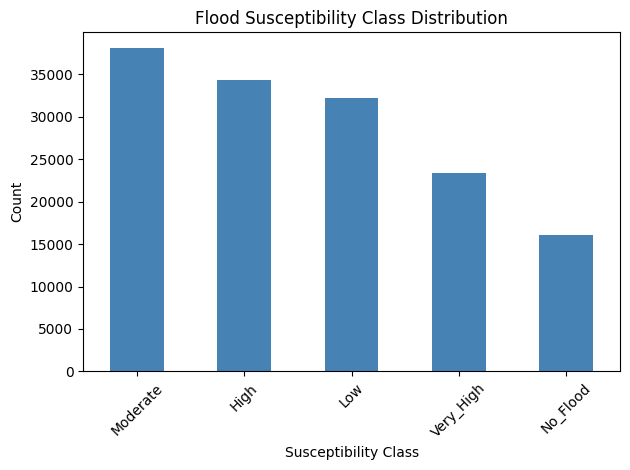

In [22]:
df['SUSCEP'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Flood Susceptibility Class Distribution')
plt.xlabel('Susceptibility Class')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


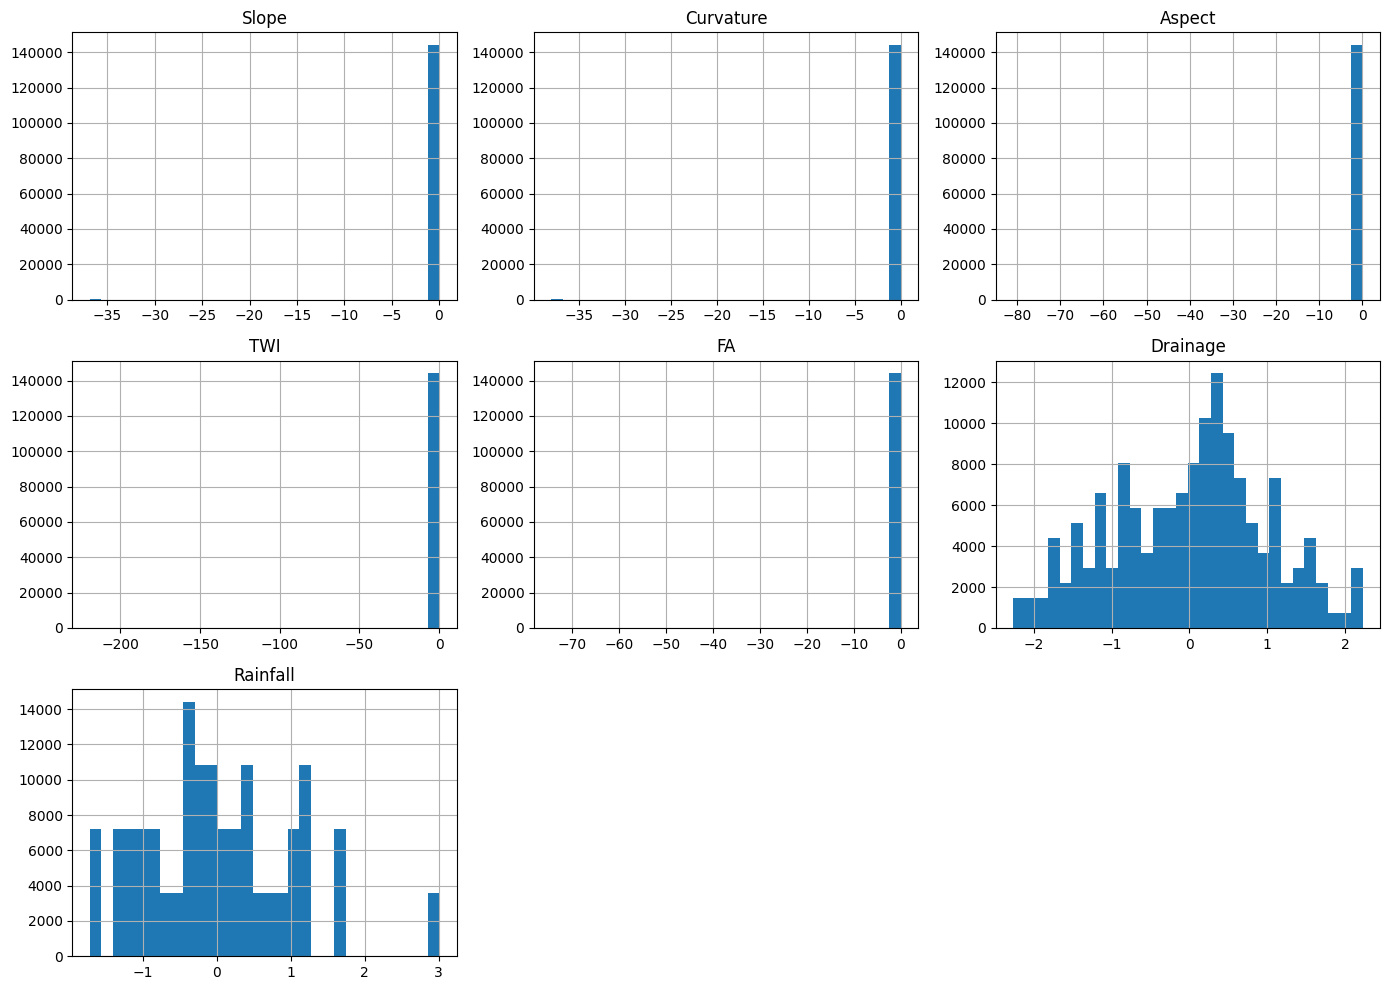

In [23]:
features = ['Slope', 'Curvature', 'Aspect', 'TWI', 'FA', 'Drainage', 'Rainfall']
df[features].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

In [27]:
df['Slope'].describe()

,Slope
count,1.441190e+05
mean,-3.352570e-18
std,1.000003e+00
min,-3.685937e+01
25%,2.713014e-02
50%,2.713014e-02
75%,2.713014e-02
max,2.713014e-02


In [28]:
df['Slope'].value_counts().head(10)

,count
Slope,
0.027130,144013
-36.859371,106


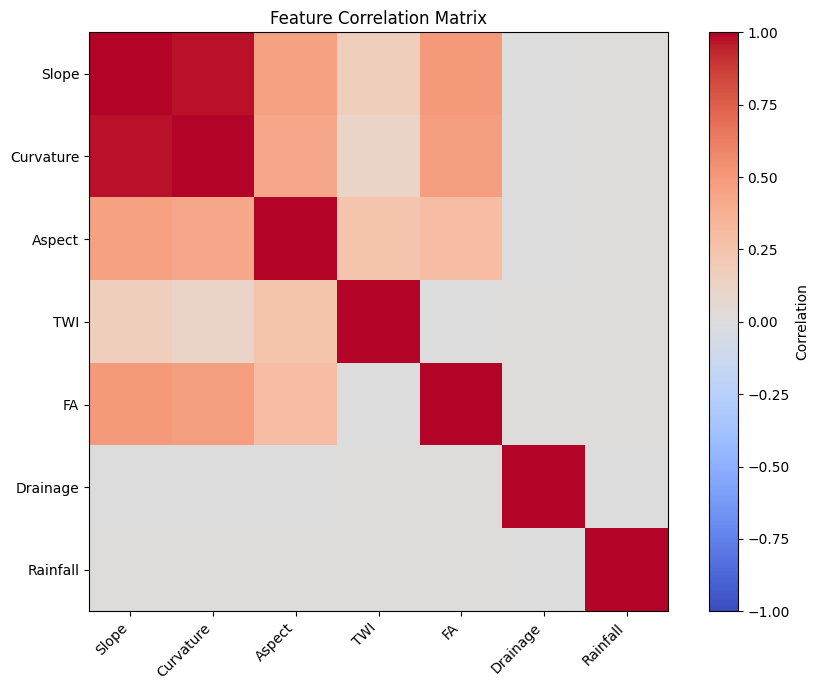

In [24]:
corr = df[features].corr()
plt.figure(figsize=(9, 7))
plt.imshow(corr, cmap='coolwarm', interpolation='none', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(features)), features, rotation=45, ha='right')
plt.yticks(range(len(features)), features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

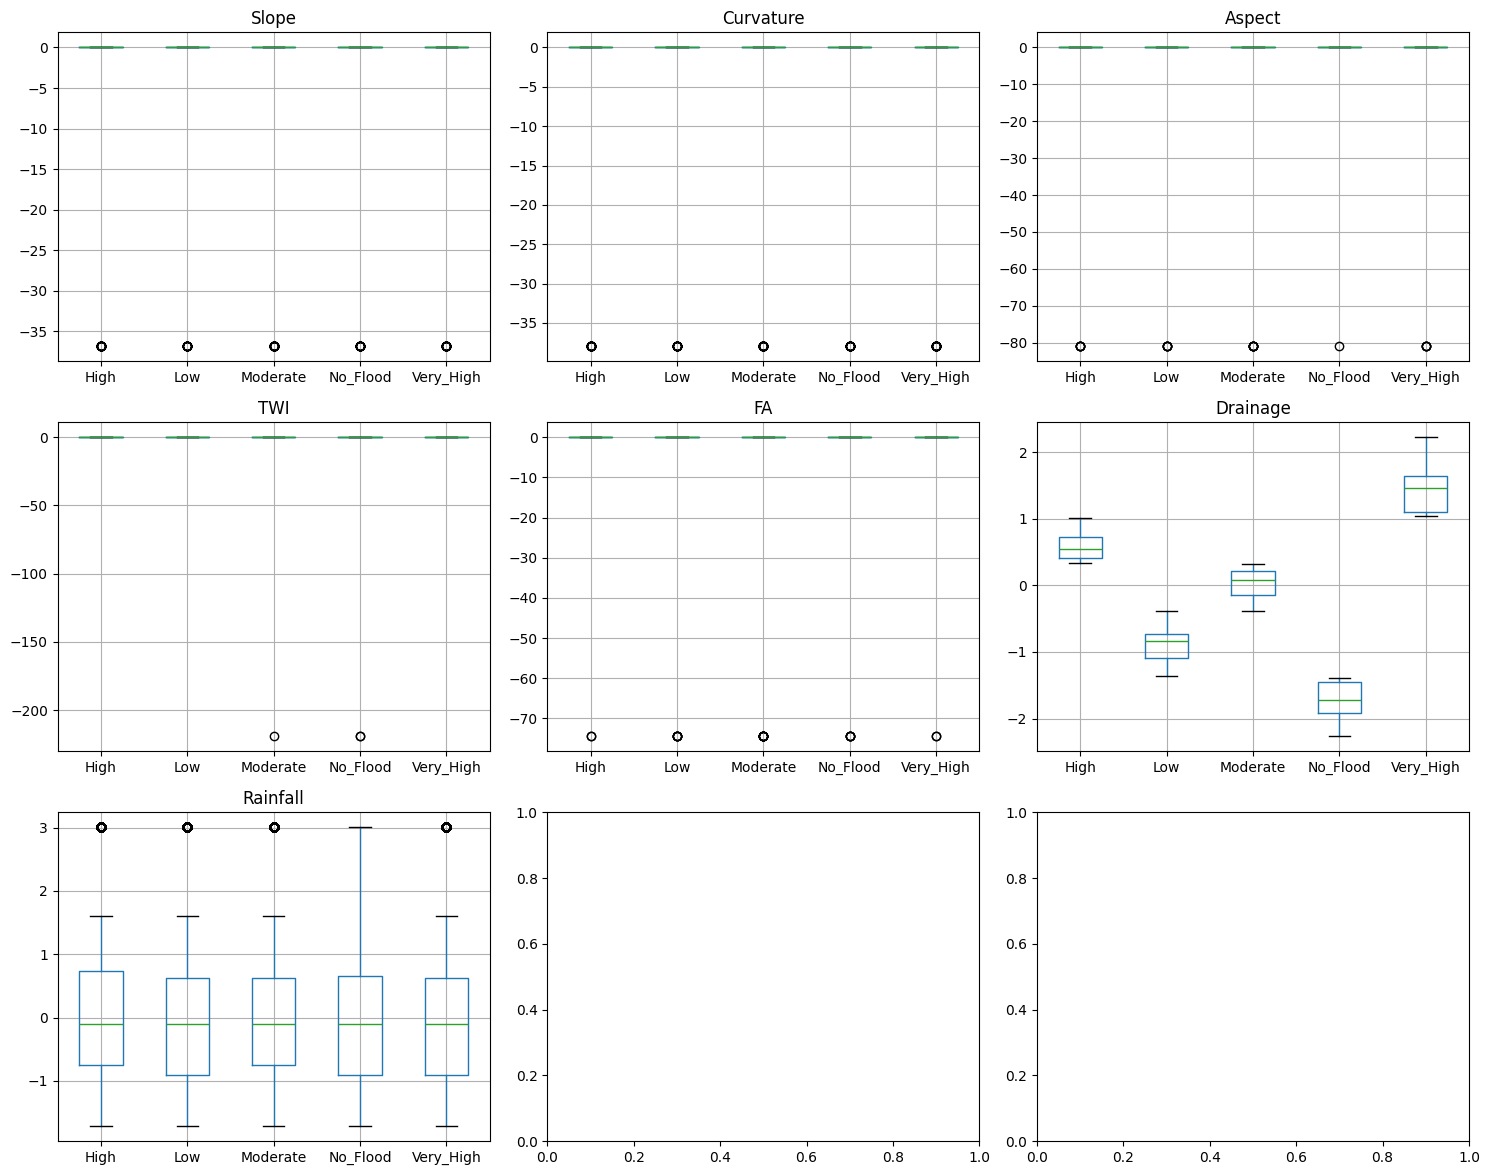

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, feat in zip(axes.flat, features):
    df.boxplot(column=feat, by='SUSCEP', ax=ax)
    ax.set_title(feat)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_457/2141341926.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(classes))


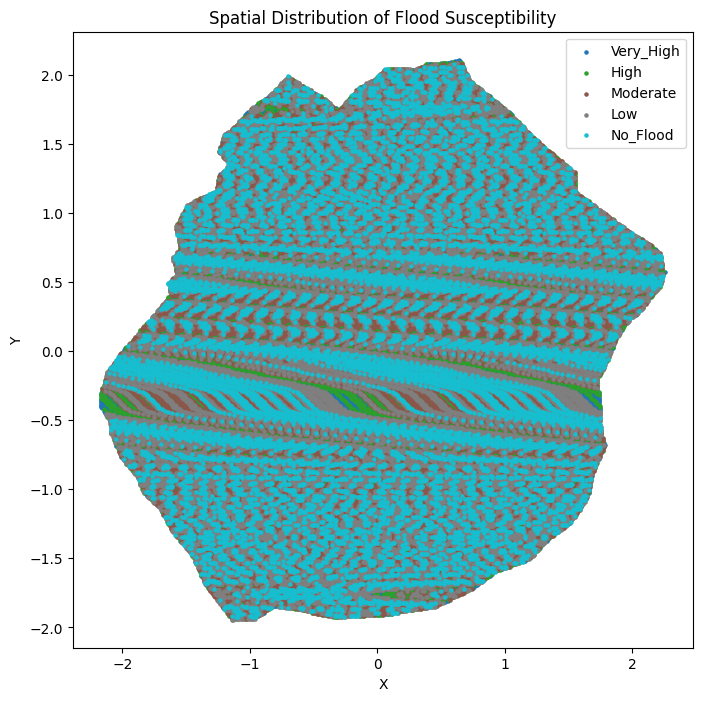

In [26]:
classes = df['SUSCEP'].unique()
colors = plt.cm.get_cmap('tab10', len(classes))
fig, ax = plt.subplots(figsize=(8, 8))
for i, cls in enumerate(classes):
    subset = df[df['SUSCEP'] == cls]
    ax.scatter(subset['X'], subset['Y'], label=cls, s=5, color=colors(i))
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Spatial Distribution of Flood Susceptibility')
ax.legend()
plt.show()

### Stage 3: Data splitting
Split dataset into:

* Training (60% of data)


* Validation (30% of data)- This is what will be use for localised testing to evaluate metrics.


* Testing (10% of data)- This is what will be used for the implementation during the real time deployment.

In [ ]:
# Data Splitting code goes here

### Stage 4: Model fitting and evaluation metrics
We will be using 3 models to fit the data:

* Decision Tree
* Random Forest
* LightGBM


Since it is a classfication dataset, metrics should cover, recall, f1-score and accuracy. Recall should be the main metrics for this project. it focuses more on reducing False Negative (look it up).

from sklearn.metrics import f1_score, recall_score accuracy_score, precision_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb

In [ ]:
# pip install lightgbm
# Run if you dont have lightGBM on your environment


In [ ]:
# Model training here